### Tahap 1 : Data Cleaning & Preproccessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
try:
    df = pd.read_csv('../data/raw/data.csv', encoding = 'ISO-8859-1')
except FileNotFoundError:
    print("data tidak ditemukan")

In [4]:
df.columns = df.columns.str.lower().str.strip()

In [5]:
print(f'dimensi awal data : {df.shape}')
print(f'\n{df.info()}')

dimensi awal data : (541909, 8)
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   invoiceno    541909 non-null  str    
 1   stockcode    541909 non-null  str    
 2   description  540455 non-null  str    
 3   quantity     541909 non-null  int64  
 4   invoicedate  541909 non-null  str    
 5   unitprice    541909 non-null  float64
 6   customerid   406829 non-null  float64
 7   country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB

None


In [6]:
# drop missing values : 'customerid'
df = df.dropna(subset=['customerid'])
# drop missing values : 'description'
df = df.dropna(subset=['description'])

In [7]:
# mengubah customerid menjadi string
df['customerid'] = df['customerid'].astype(int).astype(str)

In [8]:
df

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680,France


In [9]:
# remove duplicates
df.drop_duplicates(inplace = True)

# menghapus transaksi 'cacelled'
df = df[~df['invoiceno'].str.contains('C', na = False)]

# menghapus quantity negatif dan unitprice <= 0
df = df[(df['quantity'] > 0) & (df['unitprice'] > 0)]

# membuat kolom total sales
df['totalsales'] = df['quantity'] * df['unitprice']

# mengkonversi tipe data invoicedate ke datetime
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

In [10]:
# outlier handling
# dalam e-commerce retail, outlier quantity seringkali valid (B2B bulk purchase)

# IQR : 'unitprice'
Q1 = df['unitprice'].quantile(0.25)
Q3 = df['unitprice'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 3.0 * IQR
upper_bound = Q3 + 3.0 * IQR

df = df[(df['unitprice'] >= lower_bound) & (df['unitprice'] <= upper_bound)]

df

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,totalsales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60


### Tahap 2 : Business Metrics & Exploratory Data Analysis (EDA)

In [11]:
# set style visualisasi
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [12]:
# menambahkan kolok 'monthyear' untuk agregasi bulanan
df['monthyear'] = df['invoicedate'].dt.to_period('M')

# agregasi metrik bulanan
monthly_metrics = df.groupby('monthyear').agg({
    'totalsales' : 'sum',
    'customerid' : 'nunique',
    'invoiceno' : 'nunique'
}).rename(columns = {
    'totalsales' : 'Revenue',
    'customerid' : 'Active_Customers',
    'invoiceno' : 'Total_Orders'
})

In [13]:
monthly_metrics = monthly_metrics.reset_index()
monthly_metrics['monthyear'] = monthly_metrics['monthyear'].dt.to_timestamp()

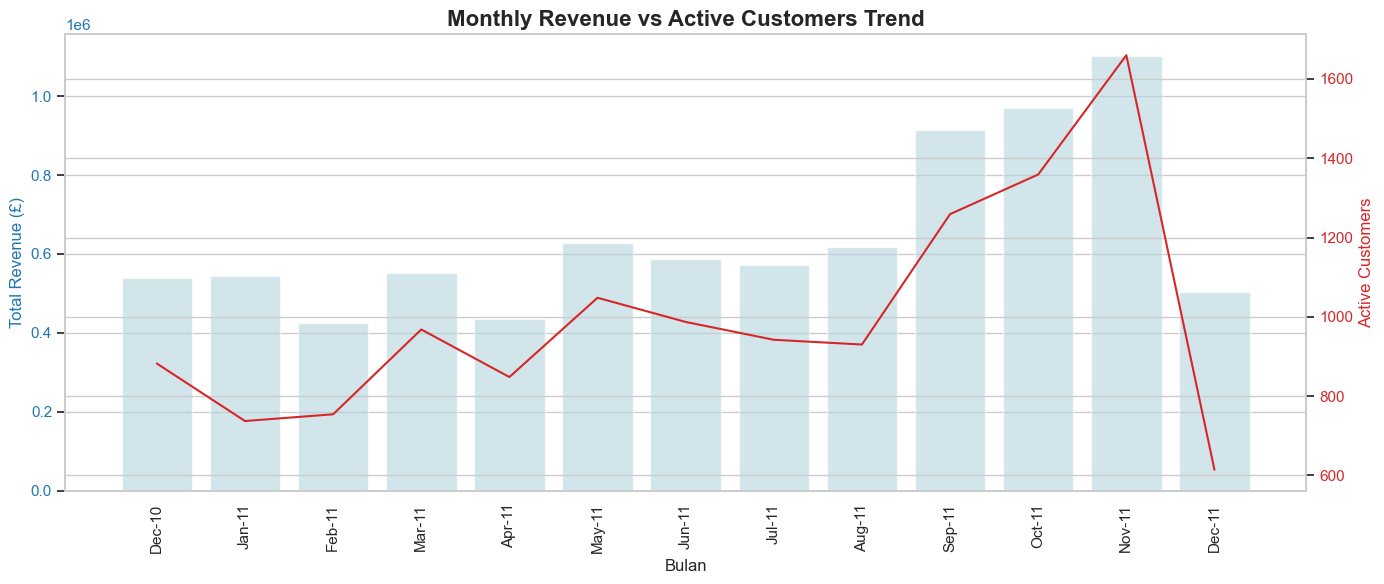

In [14]:
# --- Visualisasi Tren Penjualan & Pelanggan ---
fig, ax1 = plt.subplots(figsize = (14, 6))

# plot revenue (bar chart)
color = 'tab:blue'
ax1.set_xlabel('Bulan')
ax1.set_ylabel('Total Revenue (£)', color=color)
sns.barplot(x='monthyear', y='Revenue', data=monthly_metrics, color='lightblue', ax=ax1, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(range(len(monthly_metrics)))
ax1.set_xticklabels(monthly_metrics['monthyear'].dt.strftime('%b-%y'), rotation=90)

# Plot Active Customers (Line Chart) di Axis kedua
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Active Customers', color=color)
sns.lineplot(x=range(len(monthly_metrics)), y = 'Active_Customers', data=monthly_metrics, color=color, ax=ax2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Monthly Revenue vs Active Customers Trend', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

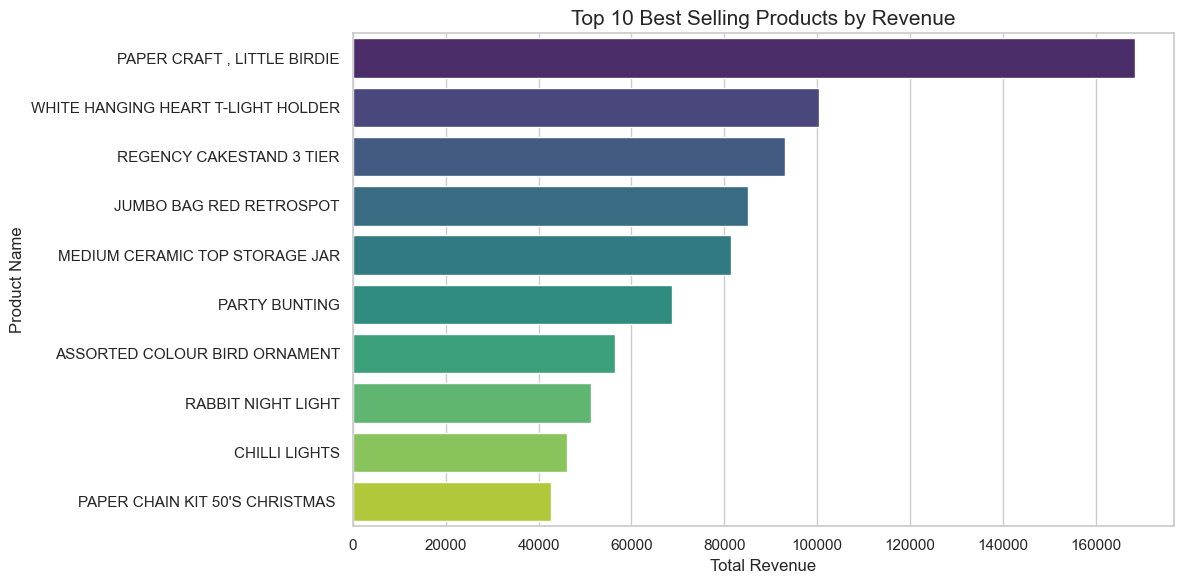

In [15]:
# --- produk terlaris ---
top_products = df.groupby('description')['totalsales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.values, y=top_products.index, hue = top_products.index, palette='viridis', legend = False)
plt.title('Top 10 Best Selling Products by Revenue', fontsize=15)
plt.xlabel('Total Revenue')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

Top 5 Countries by Revenue:
country
United Kingdom    6951418.084
Netherlands        278303.290
EIRE               238388.570
Germany            199004.450
France             176385.040
Name: totalsales, dtype: float64


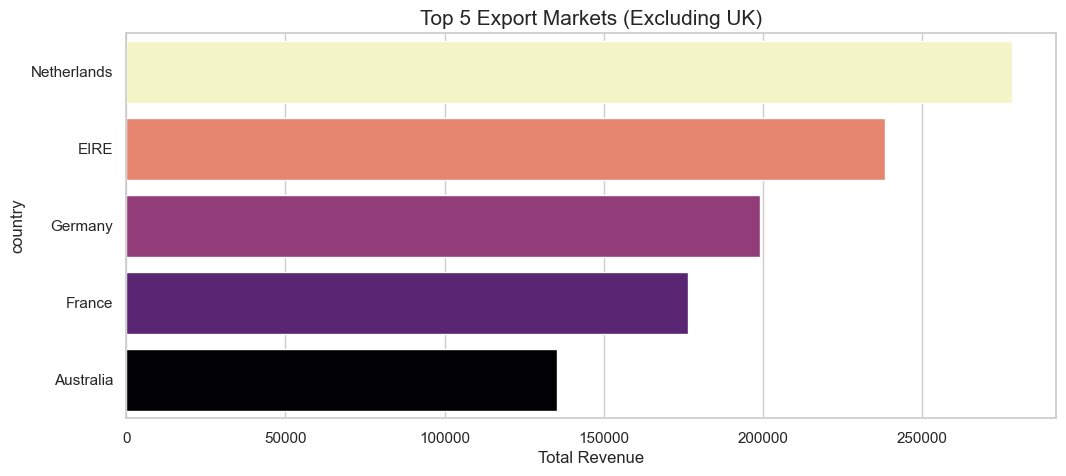

In [16]:
# --- analisis geografis ---
# Kita pisahkan UK karena biasanya mendominasi, untuk melihat potensi pasar luar negeri
country_sales = df.groupby('country')['totalsales'].sum().sort_values(ascending=False)

# Plot Top 5 Negara (Termasuk UK)
print("Top 5 Countries by Revenue:")
print(country_sales.head(5))

# Plot Top 5 Negara (Kecuali UK - Export Market)
plt.figure(figsize=(12, 5))
country_sales_no_uk = country_sales.drop('United Kingdom').head(5)
sns.barplot(x=country_sales_no_uk.values, y=country_sales_no_uk.index, hue = country_sales_no_uk, palette='magma', legend = False)
plt.title('Top 5 Export Markets (Excluding UK)', fontsize=15)
plt.xlabel('Total Revenue')
plt.show()

### Tahap 3 : Advance Customer Analytics (RFM & Clustering)

In [17]:
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [18]:
# Tentukan Tanggal Snapshot (Seolah-olah kita analisis sehari setelah data terakhir)
snapshot_date = df['invoicedate'].max() + dt.timedelta(days=1)

# Hitung RFM Metrics per Customer
rfm = df.groupby('customerid').agg({
    'invoicedate': lambda x: (snapshot_date - x.max()).days, # Recency
    'invoiceno': 'nunique',                                  # Frequency
    'totalsales': 'sum'                                     # Monetary
})

# Rename kolom agar lebih rapi
rfm.rename(columns={
    'invoicedate': 'Recency',
    'invoiceno': 'Frequency',
    'totalsales': 'Monetary'
}, inplace=True)

print(f"Data RFM siap. Total Customer: {rfm.shape[0]}")
rfm.head()

Data RFM siap. Total Customer: 4321


,Recency,Frequency,Monetary
customerid,,,
12346,326,1,77183.60
12347,2,7,4118.75
12348,75,4,1437.24
12349,19,1,1328.55
12350,310,1,294.40


In [19]:
# Menangani Skewness dengan Log Transformation (Hanya untuk keperluan modeling)
rfm_log = np.log1p(rfm) # log1p digunakan untuk menghindari log(0)

# Standard Scaling (Mengubah data ke skala yang sama, mean=0, std=1)
scaler = StandardScaler()
rfm_normalized = scaler.fit_transform(rfm_log)

# Ubah kembali ke DataFrame untuk kemudahan
rfm_normalized = pd.DataFrame(rfm_normalized, index=rfm.index, columns=rfm.columns)

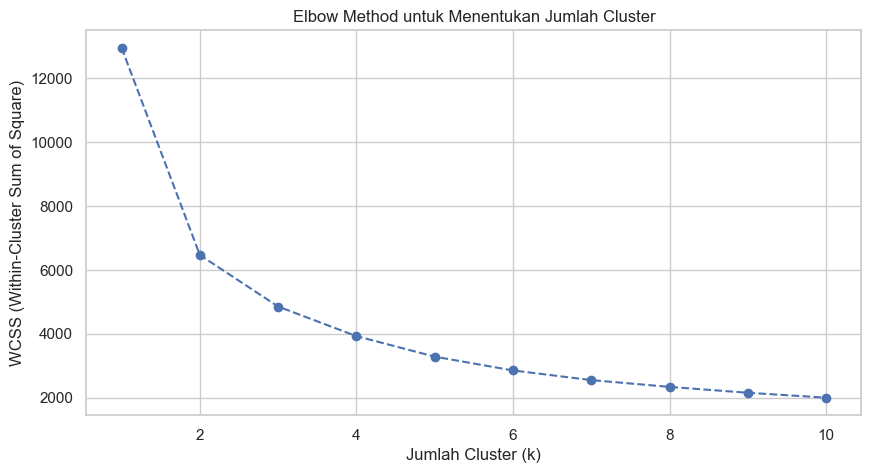

In [20]:
# Mencari jumlah cluster optimal (Elbow Method)
wcss = []
range_n_clusters = range(1, 11)

for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(rfm_normalized)
    wcss.append(kmeans.inertia_)

# Visualisasi Elbow Plot
plt.figure(figsize=(10, 5))
plt.plot(range_n_clusters, wcss, marker='o', linestyle='--')
plt.title('Elbow Method untuk Menentukan Jumlah Cluster')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Square)')
plt.show()

In [21]:
# Fit K-Means dengan k=3
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans.fit(rfm_normalized)

# Masukkan label cluster ke data RFM asli (bukan data yang di-log/scale)
rfm['Cluster'] = kmeans.labels_

# Analisis Karakteristik Tiap Cluster (Snake Plot / Summary)
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

print(cluster_summary)

        Recency Frequency Monetary      
           mean      mean     mean count
Cluster                                 
0         15.81     13.56  7736.06   732
1        165.65      1.35   340.35  1889
2         43.91      3.44  1222.43  1700


### Tahap 4 : Market Basket Analysis & Final Data Export

In [22]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

In [23]:
# Mempersiapkan Keranjang Belanja (Basket)
# Kita filter 'France' sebagai contoh kasus (Market spesifik)
# Kita kelompokkan berdasarkan InvoiceNo dan Description
basket = (
    df[df["country"] == "France"]
    .groupby(["invoiceno", "description"])["quantity"]
    .sum()
    .unstack()
    .reset_index()
    .fillna(0)
    .set_index("invoiceno")
)

# One Hot Encoding (Mengubah jumlah barang menjadi 0 atau 1)
# Kita hanya ingin tahu 'beli' atau 'tidak', bukan berapa banyaknya
basket_sets = basket.map(lambda x: True if x >= 1 else False)

# Hapus kolom 'POSTAGE' (Biaya kirim) agar tidak mengganggu analisis produk
if 'POSTAGE' in basket_sets.columns:
    basket_sets.drop('POSTAGE', inplace=True, axis=1)

# Menjalankan Algoritma Apriori
# min_support=0.07 artinya barang minimal muncul di 7% dari seluruh transaksi
frequent_itemsets = apriori(basket_sets, min_support=0.07, use_colnames=True)

# Membuat Aturan Asosiasi (Association Rules)
# metric="lift" adalah indikator kekuatan hubungan
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# Menampilkan Hasil Terbaik
# Kita cari yang Lift-nya tinggi dan Confidence tinggi
result_mba = rules.sort_values("lift", ascending=False).head(10)

print("Top 10 Product Association Rules (Bundling Ideas):")
result_mba_display = result_mba.copy()
result_mba_display['antecedents'] = result_mba_display['antecedents'].apply(lambda x: ', '.join(list(x)))
result_mba_display['consequents'] = result_mba_display['consequents'].apply(lambda x: ', '.join(list(x)))

print(result_mba_display[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

Top 10 Product Association Rules (Bundling Ideas):
                                          antecedents  \
3                          ALARM CLOCK BAKELIKE GREEN   
2                           ALARM CLOCK BAKELIKE RED    
5                           ALARM CLOCK BAKELIKE RED    
4                           ALARM CLOCK BAKELIKE PINK   
29                      SET/6 RED SPOTTY PAPER PLATES   
28  SET/6 RED SPOTTY PAPER CUPS, SET/20 RED RETROS...   
1                          ALARM CLOCK BAKELIKE GREEN   
0                           ALARM CLOCK BAKELIKE PINK   
27  SET/6 RED SPOTTY PAPER PLATES, SET/20 RED RETR...   
30                        SET/6 RED SPOTTY PAPER CUPS   

                                          consequents   support  confidence  \
3                           ALARM CLOCK BAKELIKE RED   0.082228    0.815789   
2                          ALARM CLOCK BAKELIKE GREEN  0.082228    0.837838   
5                           ALARM CLOCK BAKELIKE PINK  0.076923    0.783784   
4    

In [24]:
rfm_reset = rfm.reset_index()

df_final = pd.merge(
    df,
    rfm_reset[['customerid', 'Recency', 'Frequency', 'Monetary', 'Cluster']],
    on = 'customerid',
    how = 'left'
)

cluster_map = {
    0 : 'Loyal Customers',
    1: 'At Risk / Low Value',
    2: 'Champions / Whales'
}
df_final['customer_segment'] = df_final['Cluster'].map(cluster_map)

df_final.to_csv('../data/processed/Ecommerce_Cleaned_With_Segments.csv', index=False)

print('data berhasil disimpan')

data berhasil disimpan


In [25]:
rules_cleaned = rules.copy()

rules_cleaned['antecedents'] = rules_cleaned['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_cleaned['consequents'] = rules_cleaned['consequents'].apply(lambda x: ', '.join(list(x)))

rules_cleaned.to_csv('../data/processed/Product_Association_Rules.csv', index=False)